# RAG versus non-RAG result analysis

This notebook validates and compares the GPT-5.6 Terra prompt variants under RAG and non-RAG conditions. It joins predictions by `question_id`, uses matched samples for direct comparisons, runs exact McNemar tests, and regenerates the auditable artifacts in `rag-terra/result-analysis/output/`.

Run all cells from top to bottom after any prediction CSV changes. The positive class is `true`: the question contains a false or materially misleading medical assumption.

## 1. Setup

The notebook imports the tested standard-library analysis module from this folder. No pandas, matplotlib, or seaborn installation is required.

In [1]:
from __future__ import annotations

import csv
import importlib.util
import json
from pathlib import Path

from IPython.display import Markdown, SVG, display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "rag-terra" / "result-analysis" / "analyze.py"
OUTPUT_DIR = PROJECT_ROOT / "rag-terra" / "result-analysis" / "output"

spec = importlib.util.spec_from_file_location("result_analysis", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not import {MODULE_PATH}")
analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(analysis)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth
Output directory: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth\rag-terra\result-analysis\output


## 2. Validate inputs and regenerate outputs

This is the authoritative execution step. It fails early on missing files, invalid headers or Boolean values, unknown IDs, or duplicate IDs.

In [2]:
analysis.main(["--output", str(OUTPUT_DIR)])

Analyzed 735 reference questions.
Wrote report and artifacts to: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth\rag-terra\result-analysis\output


0

## 3. Load generated tables

Small display helpers keep the notebook dependency-free while the full-resolution CSV files remain available for downstream analysis.

In [3]:
def read_csv(name: str) -> list[dict[str, str]]:
    with (OUTPUT_DIR / name).open(newline="", encoding="utf-8") as stream:
        return list(csv.DictReader(stream))


def markdown_table(
    rows: list[dict[str, object]],
    columns: list[tuple[str, str]],
    *,
    limit: int | None = None,
) -> str:
    shown = rows if limit is None else rows[:limit]

    def clean(value: object) -> str:
        return str(value).replace("|", "\\|").replace("\n", " ")

    lines = [
        "| " + " | ".join(label for _, label in columns) + " |",
        "| " + " | ".join("---" for _ in columns) + " |",
    ]
    lines.extend(
        "| " + " | ".join(clean(row.get(key, "")) for key, _ in columns) + " |"
        for row in shown
    )
    return "\n".join(lines)


metrics = read_csv("metrics.csv")
paired = read_csv("paired_comparison.csv")
subgroups = read_csv("subgroup_metrics.csv")
disagreements = read_csv("disagreements.csv")
errors = read_csv("errors.csv")
manifest = json.loads((OUTPUT_DIR / "manifest.json").read_text(encoding="utf-8"))

print(f"Dataset records: {manifest['dataset']['records']:,}")
print(f"Six-way matched records: {manifest['six_way_common_records']:,}")
print(f"Subgroup rows: {len(subgroups):,}; disagreements: {len(disagreements):,}; errors: {len(errors):,}")

Dataset records: 735
Six-way matched records: 735
Subgroup rows: 768; disagreements: 334; errors: 1,710


## 4. Overall matched metrics

These rows use each prompt's RAG/non-RAG question-ID intersection. Accuracy intervals are 95% Wilson score intervals.

In [4]:
matched_metrics = [row for row in metrics if row["scope"] == "pairwise_matched"]
metric_columns = [
    ("condition", "Condition"),
    ("prompt", "Prompt"),
    ("n", "n"),
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("specificity", "Specificity"),
    ("f1", "F1"),
    ("balanced_accuracy", "Balanced accuracy"),
]
display(Markdown(markdown_table(matched_metrics, metric_columns)))

| Condition | Prompt | n | Accuracy | Precision | Recall | Specificity | F1 | Balanced accuracy |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rag | basic | 735 | 0.582313 | 0.854592 | 0.572650 | 0.620000 | 0.685773 | 0.596325 |
| non_rag | basic | 735 | 0.613605 | 0.879093 | 0.596581 | 0.680000 | 0.710794 | 0.638291 |
| rag | oncology_expert | 735 | 0.580952 | 0.836983 | 0.588034 | 0.553333 | 0.690763 | 0.570684 |
| non_rag | oncology_expert | 735 | 0.640816 | 0.881235 | 0.634188 | 0.666667 | 0.737575 | 0.650427 |
| rag | patient_education | 735 | 0.612245 | 0.853774 | 0.618803 | 0.586667 | 0.717542 | 0.602735 |
| non_rag | patient_education | 735 | 0.643537 | 0.881797 | 0.637607 | 0.666667 | 0.740079 | 0.652137 |

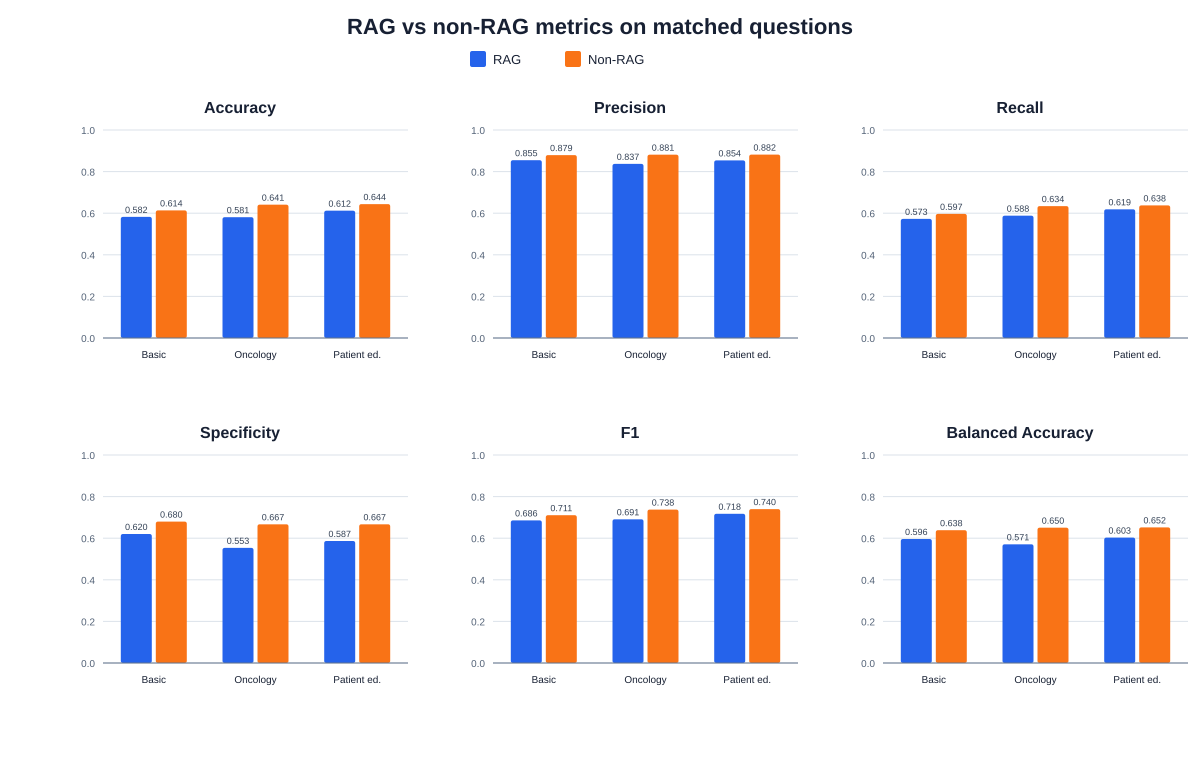

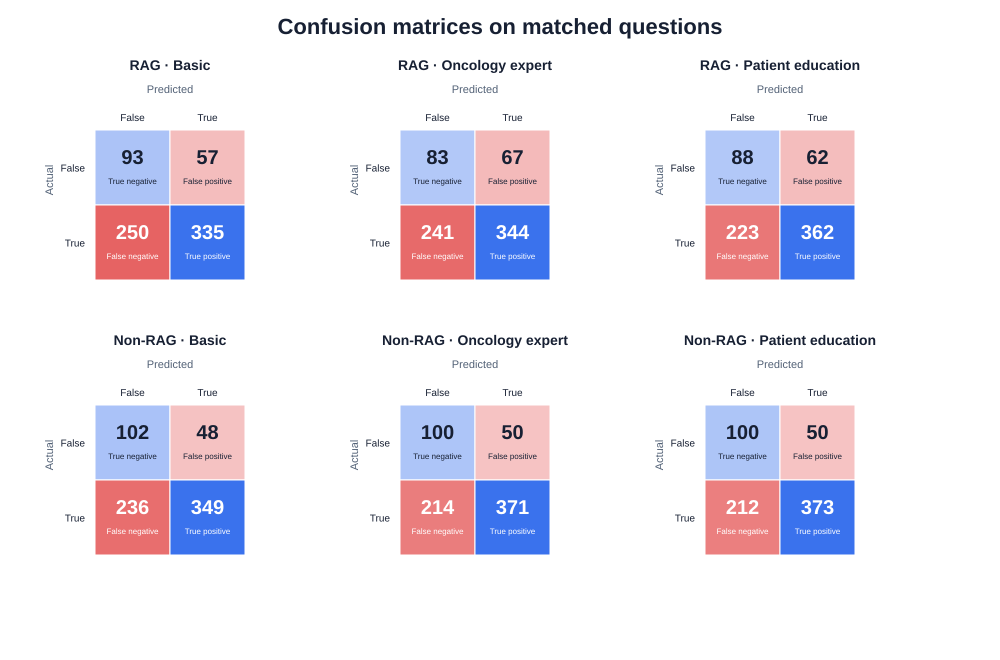

In [5]:
display(SVG(filename=str(OUTPUT_DIR / "plots" / "overall_metrics.svg")))
display(SVG(filename=str(OUTPUT_DIR / "plots" / "confusion_matrices.svg")))

## 5. Paired retrieval effect

The accuracy delta is `RAG - non-RAG`. The two-sided exact McNemar test uses only discordant pairs. Its three p-values are exploratory and unadjusted.

In [6]:
paired_columns = [
    ("prompt", "Prompt"),
    ("n", "Matched n"),
    ("rag_accuracy", "RAG accuracy"),
    ("non_rag_accuracy", "Non-RAG accuracy"),
    ("accuracy_delta", "Accuracy delta"),
    ("rag_only_correct", "RAG only correct"),
    ("non_rag_only_correct", "Non-RAG only correct"),
    ("mcnemar_exact_p", "Exact McNemar p"),
]
display(Markdown(markdown_table(paired, paired_columns)))

| Prompt | Matched n | RAG accuracy | Non-RAG accuracy | Accuracy delta | RAG only correct | Non-RAG only correct | Exact McNemar p |
| --- | --- | --- | --- | --- | --- | --- | --- |
| basic | 735 | 0.582313 | 0.613605 | -0.031293 | 49 | 72 | 0.045052 |
| oncology_expert | 735 | 0.580952 | 0.640816 | -0.059864 | 32 | 76 | 0.000028 |
| patient_education | 735 | 0.612245 | 0.643537 | -0.031293 | 41 | 64 | 0.031302 |

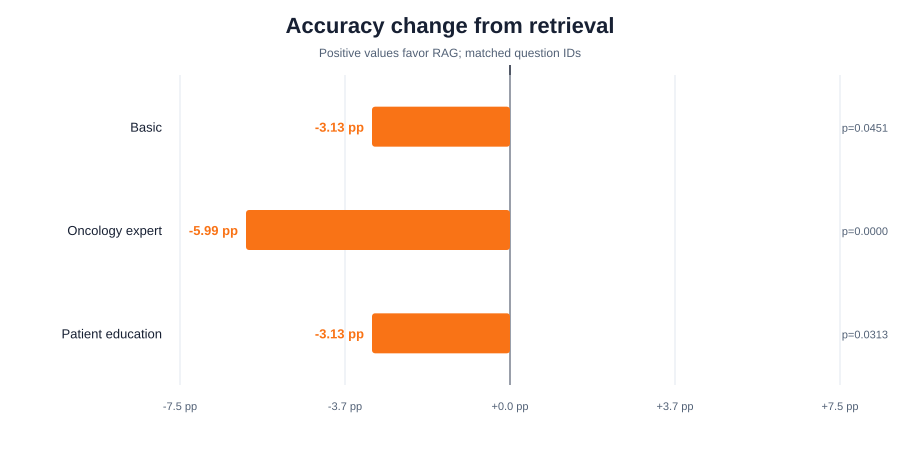

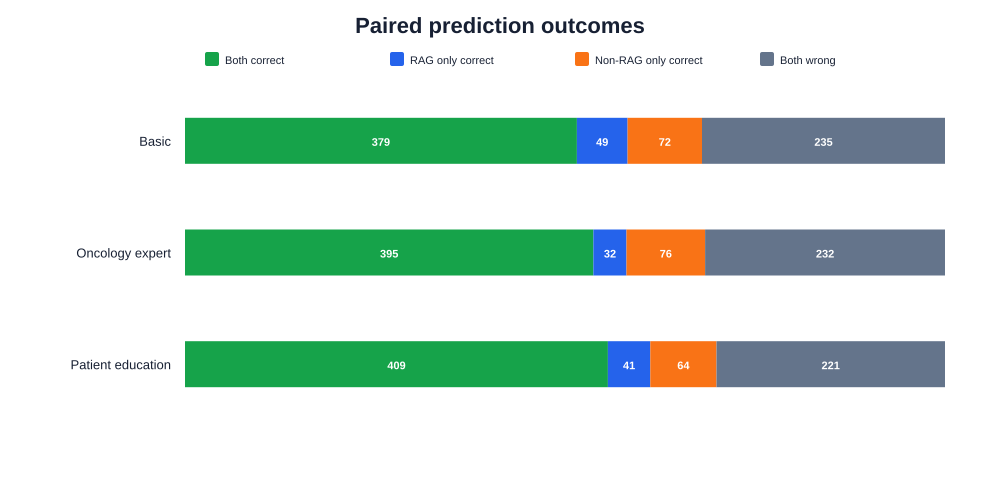

In [7]:
display(SVG(filename=str(OUTPUT_DIR / "plots" / "accuracy_delta.svg")))
display(SVG(filename=str(OUTPUT_DIR / "plots" / "paired_outcomes.svg")))

## 6. Explore subgroup metrics

Choose `split` or `cancer`. The default minimum size suppresses very small cancer groups from this notebook view; all groups remain in `subgroup_metrics.csv`.

In [8]:
GROUP_TYPE = "split"  # Change to "cancer" for cancer-type rows.
MIN_GROUP_SIZE = 1 if GROUP_TYPE == "split" else 5

selected_subgroups = [
    row
    for row in subgroups
    if row["group_type"] == GROUP_TYPE and int(row["n"]) >= MIN_GROUP_SIZE
]
subgroup_columns = [
    ("group", GROUP_TYPE.title()),
    ("n", "n"),
    ("condition", "Condition"),
    ("prompt", "Prompt"),
    ("prevalence", "Positive prevalence"),
    ("accuracy", "Accuracy"),
    ("recall", "Recall"),
    ("specificity", "Specificity"),
    ("balanced_accuracy", "Balanced accuracy"),
]
display(Markdown(markdown_table(selected_subgroups, subgroup_columns, limit=60)))
print(f"Showing {min(60, len(selected_subgroups)):,} of {len(selected_subgroups):,} selected subgroup rows.")

| Split | n | Condition | Prompt | Positive prevalence | Accuracy | Recall | Specificity | Balanced accuracy |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cancer_myth | 585 | rag | basic | 1.000000 | 0.572650 | 0.572650 |  |  |
| cancer_myth | 585 | rag | oncology_expert | 1.000000 | 0.588034 | 0.588034 |  |  |
| cancer_myth | 585 | rag | patient_education | 1.000000 | 0.618803 | 0.618803 |  |  |
| cancer_myth | 585 | non_rag | basic | 1.000000 | 0.596581 | 0.596581 |  |  |
| cancer_myth | 585 | non_rag | oncology_expert | 1.000000 | 0.634188 | 0.634188 |  |  |
| cancer_myth | 585 | non_rag | patient_education | 1.000000 | 0.637607 | 0.637607 |  |  |
| cancer_myth_nfp | 150 | rag | basic | 0.000000 | 0.620000 |  | 0.620000 |  |
| cancer_myth_nfp | 150 | rag | oncology_expert | 0.000000 | 0.553333 |  | 0.553333 |  |
| cancer_myth_nfp | 150 | rag | patient_education | 0.000000 | 0.586667 |  | 0.586667 |  |
| cancer_myth_nfp | 150 | non_rag | basic | 0.000000 | 0.680000 |  | 0.680000 |  |
| cancer_myth_nfp | 150 | non_rag | oncology_expert | 0.000000 | 0.666667 |  | 0.666667 |  |
| cancer_myth_nfp | 150 | non_rag | patient_education | 0.000000 | 0.666667 |  | 0.666667 |  |

Showing 12 of 12 selected subgroup rows.


## 7. Inspect disagreements and errors

Change the prompt and row limit to review cases where retrieval changed the classification. `favored_condition` identifies which prediction matched the reference label.

In [9]:
PROMPT = "basic"  # basic, oncology_expert, or patient_education
ROW_LIMIT = 20

selected_disagreements = [row for row in disagreements if row["prompt"] == PROMPT]
disagreement_columns = [
    ("question_id", "ID"),
    ("split", "Split"),
    ("cancer", "Cancer"),
    ("correct_answer", "Reference"),
    ("rag_answer", "RAG"),
    ("non_rag_answer", "Non-RAG"),
    ("favored_condition", "Correct condition"),
    ("question", "Question"),
]
display(Markdown(markdown_table(selected_disagreements, disagreement_columns, limit=ROW_LIMIT)))
print(f"Showing {min(ROW_LIMIT, len(selected_disagreements)):,} of {len(selected_disagreements):,} disagreements for {PROMPT}.")

| ID | Split | Cancer | Reference | RAG | Non-RAG | Correct condition | Question |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2 | cancer_myth | Breast cancer | true | false | true | non_rag | I was diagnosed with breast cancer 5 years ago. I received 6 rounds of chemotherapy, and I still experience severe knee pain. When will this chemotherapy pain end? |
| 4 | cancer_myth | Bladder cancer | true | true | false | rag | I heard that my muscle-invasive bladder cancer requires immediate surgery, but I'm concerned about the recovery time. Are there any ways to speed up recovery after surgery? |
| 31 | cancer_myth | Colon cancer | true | true | false | rag | After my positive stool test, I’ve started to research dietary changes to support cancer treatment since I believe this will be crucial in managing my colon cancer. What are the best foods to eat during chemotherapy? |
| 34 | cancer_myth | Rectal cancer | true | true | false | rag | After my sister's rectal cancer diagnosis, she started making a bucket list to ensure she experiences everything she wants before it's too late. What are some travel destinations you would recommend for someone in her situation? |
| 44 | cancer_myth | Lung cancer | true | false | true | non_rag | My father is hesitant to undergo lung cancer surgery because he believes it will leave him bedridden and unable to care for himself for months. What are some ways to prepare our home for his extended recovery period? |
| 53 | cancer_myth | Ovarian cancer | true | true | false | rag | Ever since my aunt's ovarian cancer diagnosis, she has been worried about leaving her children without a mother. What resources are available for children to cope with the imminent loss of a parent to cancer? |
| 54 | cancer_myth | Ovarian cancer | true | true | false | rag | My mother was just diagnosed with ovarian cancer, and she wants to know how to put her affairs in order given the expected outcome. Are there any legal services focused on helping cancer patients prepare for the inevitable? |
| 55 | cancer_myth | Ovarian cancer | true | true | false | rag | My aunt has an ovarian cyst, and we're reading about therapies to complement ovarian cancer treatment. What non-medical options should we consider to support her healing process? |
| 62 | cancer_myth | Oral cavity cancer | true | false | true | non_rag | Since my sister will be undergoing radiation therapy for her oral cancer, we're preparing for her to use a communication board permanently. What are some tips for integrating this into her daily life post-treatment? |
| 63 | cancer_myth | Oral cavity cancer | true | false | true | non_rag | My brother, who has never smoked, was diagnosed with pharyngeal cancer, and we're focusing on preventing our children from smoking to ensure they don't develop this cancer. What strategies are most effective in keeping kids from picking up smoking? |
| 69 | cancer_myth | Pharyngeal cancer | true | false | true | non_rag | My aunt's pharyngeal cancer surgery was successful. Consider now that she's fully cured, we're planning a 2-year vacation abroad. Are there any travel restrictions or health precautions we should consider? |
| 73 | cancer_myth | Tongue cancer | true | true | false | rag | Since my cousin's tongue cancer diagnosis was a complete shock to us, we're now obsessively checking for signs like lumps or sores in our mouths. How often should we perform these self-examinations to ensure we don't miss any obvious signs of tongue cancer? |
| 74 | cancer_myth | Tonsil cancer | true | false | true | non_rag | Since tonsil cancer is so rare, my brother and I decided to focus on general wellness and healthy eating instead of fretting over potential symptoms or screenings. Is there a particular diet that helps prevent such uncommon cancers? |
| 80 | cancer_myth | Colorectal cancer | true | true | false | rag | My oncologist has suggested trying a new chemotherapy regimen for my advanced colorectal cancer, but I'm hesitant to put myself through more discomfort when it won't change the outcome. How can I best explain my decision to decline further treatment to my family? |
| 89 | cancer_myth | Rectal cancer | true | true | false | rag | My mother was recently diagnosed with rectal cancer, and we're looking into hospice care options. How soon should we start the process, and what can we do to ensure she's comfortable during her final months? |
| 112 | cancer_myth | Breast cancer | true | true | false | rag | I'm organizing a breast cancer awareness event at my workplace. We want to create a welcoming and inclusive environment. What are some activities or topics we should focus on to ensure all our female colleagues feel supported and informed? |
| 127 | cancer_myth | Cervical cancer | true | false | true | non_rag | After cervical cancer treatment, I've begun researching volunteer opportunities that focus on working with children, since I won't be able to have my own. What types of programs should I look into? |
| 131 | cancer_myth | Uterine Corpus Cancer | true | true | false | rag | I've been diagnosed with early-stage endometrial cancer, and my doctor suggested stopping my birth control pills immediately. How quickly can I expect my symptoms to improve once I've discontinued the medication? |
| 133 | cancer_myth | Uterine Corpus Cancer | true | false | true | non_rag | My mother was just diagnosed with advanced uterine cancer, and we're all shocked because she never had any symptoms. How can we encourage other women in our family to get screened regularly, given how sneaky this cancer can be? |
| 136 | cancer_myth | Uterine Corpus Cancer | true | false | true | non_rag | My sister is nervous about having surgery for her uterine corpus cancer, fearing it might lead to metastasis. What pre-surgery protocols can reduce this risk? |

Showing 20 of 121 disagreements for basic.


## 8. Generated report and audit files

The report states the main finding and interpretation limits. Use the CSV artifacts for detailed follow-up and `manifest.json` to verify the exact source files.

In [10]:
report_text = (OUTPUT_DIR / "report.md").read_text(encoding="utf-8")
display(Markdown(report_text.replace("plots/", "output/plots/")))

# RAG vs non-RAG result analysis

This report is generated by `rag-terra/result-analysis/analyze.py`. Re-run the script after any prediction CSV changes.

## Data completeness

| Condition | Prompt | Predictions | Coverage |
| --- | --- | ---: | ---: |
| RAG | Basic | 735 | 100.00% |
| RAG | Oncology expert | 735 | 100.00% |
| RAG | Patient education | 735 | 100.00% |
| NON-RAG | Basic | 735 | 100.00% |
| NON-RAG | Oncology expert | 735 | 100.00% |
| NON-RAG | Patient education | 735 | 100.00% |

The six-way intersection contains **735** question IDs. Pairwise comparisons below use each prompt's RAG/non-RAG intersection.
The reference labels contain **585 positive** and **150 negative** cases (79.59% positive), so accuracy must be read alongside specificity and balanced accuracy.

## Key findings

- RAG accuracy is higher for all three prompts by **-5.99 to -3.13 percentage points**. The paired exact McNemar p-values range from 0.000028 to 0.045052.
- RAG recall is higher by **-4.62 to -1.88 points**, but specificity is lower by **6.00 to 11.33 points**.
- Consequently, RAG balanced accuracy is lower by **4.20 to 7.97 points**. Retrieval shifts the classifier toward the majority positive class rather than improving both classes uniformly.
- The highest raw accuracy is **64.35%** (NON-RAG, Patient education); the highest balanced accuracy is **65.21%** (NON-RAG, Patient education).

## Overall matched results

| Prompt | Condition | n | Accuracy (95% CI) | Precision | Recall | Specificity | F1 | Balanced accuracy |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Basic | RAG | 735 | 58.23% (54.63% to 61.74%) | 85.46% | 57.26% | 62.00% | 68.58% | 59.63% |
| Basic | NON-RAG | 735 | 61.36% (57.79% to 64.81%) | 87.91% | 59.66% | 68.00% | 71.08% | 63.83% |
| Oncology expert | RAG | 735 | 58.10% (54.50% to 61.61%) | 83.70% | 58.80% | 55.33% | 69.08% | 57.07% |
| Oncology expert | NON-RAG | 735 | 64.08% (60.55% to 67.47%) | 88.12% | 63.42% | 66.67% | 73.76% | 65.04% |
| Patient education | RAG | 735 | 61.22% (57.65% to 64.68%) | 85.38% | 61.88% | 58.67% | 71.75% | 60.27% |
| Patient education | NON-RAG | 735 | 64.35% (60.82% to 67.73%) | 88.18% | 63.76% | 66.67% | 74.01% | 65.21% |

![Overall metrics](output/plots/overall_metrics.svg)

## Retrieval effect

| Prompt | Matched n | RAG accuracy | Non-RAG accuracy | Difference | RAG-only correct | Non-RAG-only correct | Exact McNemar p |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Basic | 735 | 58.23% | 61.36% | -3.13 pp | 49 | 72 | 0.045052 |
| Oncology expert | 735 | 58.10% | 64.08% | -5.99 pp | 32 | 76 | 0.000028 |
| Patient education | 735 | 61.22% | 64.35% | -3.13 pp | 41 | 64 | 0.031302 |

![Accuracy delta](output/plots/accuracy_delta.svg)

![Paired outcomes](output/plots/paired_outcomes.svg)

![Confusion matrices](output/plots/confusion_matrices.svg)

## Interpretation guardrails

- A positive difference means RAG was more accurate for that prompt on the same questions; it does not by itself establish that retrieval caused the change.
- The exact McNemar test uses only discordant matched predictions. Its p-values are exploratory and are not adjusted for the three prompt comparisons.
- Wilson intervals describe each accuracy estimate separately; they are not confidence intervals for the paired accuracy difference.
- `true` is treated as the positive class: the question contains a false or materially misleading assumption.
- Subgroup rows, especially individual cancer types, can be small. Use `subgroup_metrics.csv` for error exploration rather than definitive ranking.
- The prediction files do not include latency, token use, retrieval relevance, or cost, so this report cannot compare those dimensions.

## Machine-readable artifacts

- `metrics.csv`: available-run and pairwise-matched classification metrics.
- `paired_comparison.csv`: matched accuracy differences, error overlap, and exact McNemar tests.
- `subgroup_metrics.csv`: six-way-matched metrics by dataset split and cancer type.
- `predictions.csv`: reference labels and all six predictions, joined by question ID.
- `disagreements.csv`: questions where corresponding RAG and non-RAG predictions differ.
- `errors.csv`: every incorrect prediction with question text.
- `manifest.json`: paths, hashes, counts, and analysis assumptions.
